In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


Matplotlib is building the font cache; this may take a moment.


In [2]:
DATA_PATH = "../data/MILK10K"

metadata = pd.read_csv(f"{DATA_PATH}/MILK10k_Training_Metadata.csv")
groundtruth = pd.read_csv(f"{DATA_PATH}/MILK10k_Training_GroundTruth.csv")
supplement = pd.read_csv(f"{DATA_PATH}/MILK10k_Training_Supplement.csv")

print(f"Metadata shape: {metadata.shape}")
print(f"Ground Truth shape: {groundtruth.shape}")
print(f"Supplement shape: {supplement.shape}")

Metadata shape: (10480, 17)
Ground Truth shape: (5240, 12)
Supplement shape: (10480, 4)


In [3]:
print("Metadata columns:")
print(metadata.columns.tolist())

print("\nGround Truth columns:")
print(groundtruth.columns.tolist())

Metadata columns:
['lesion_id', 'image_type', 'isic_id', 'attribution', 'copyright_license', 'image_manipulation', 'age_approx', 'sex', 'skin_tone_class', 'site', 'MONET_ulceration_crust', 'MONET_hair', 'MONET_vasculature_vessels', 'MONET_erythema', 'MONET_pigmented', 'MONET_gel_water_drop_fluid_dermoscopy_liquid', 'MONET_skin_markings_pen_ink_purple_pen']

Ground Truth columns:
['lesion_id', 'AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']


In [4]:
metadata.head()

,lesion_id,image_type,isic_id,attribution,copyright_license,image_manipulation,age_approx,sex,skin_tone_class,site,MONET_ulceration_crust,MONET_hair,MONET_vasculature_vessels,MONET_erythema,MONET_pigmented,MONET_gel_water_drop_fluid_dermoscopy_liquid,MONET_skin_markings_pen_ink_purple_pen
0,IL_0000652,clinical: close-up,ISIC_8149219,MILK study team,CC-BY-NC,altered,70.0,male,1,head_neck_face,0.166749,0.163601,0.002284,0.124315,0.719495,0.220399,0.237601
1,IL_0000652,dermoscopic,ISIC_4671410,MILK study team,CC-BY-NC,instrument only,70.0,male,1,head_neck_face,0.659859,0.156478,0.016397,0.032357,0.847014,0.138121,0.148776
2,IL_0003176,clinical: close-up,ISIC_3904045,MILK study team,CC-BY-NC,instrument only,45.0,female,5,head_neck_face,0.348609,0.614718,0.013415,0.447485,0.061977,0.296341,0.058006
3,IL_0003176,dermoscopic,ISIC_5371928,MILK study team,CC-BY-NC,instrument only,45.0,female,5,head_neck_face,0.392950,0.897668,0.367882,0.645776,0.122108,0.719937,0.329812
4,IL_0004688,clinical: close-up,ISIC_0791494,MILK study team,CC-BY-NC,instrument only,50.0,male,3,lower_extremity,0.889925,0.120788,0.004546,0.487298,0.036550,0.146776,0.086027


In [5]:
groundtruth.head()

,lesion_id,AKIEC,BCC,BEN_OTH,BKL,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC
0,IL_0000652,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,IL_0003176,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,IL_0004688,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,IL_0005081,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,IL_0006177,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
DATA_PATH = "../data/MILK10K"

metadata = pd.read_csv(f"{DATA_PATH}/MILK10k_Training_Metadata.csv")
groundtruth = pd.read_csv(f"{DATA_PATH}/MILK10k_Training_GroundTruth.csv")
supplement = pd.read_csv(f"{DATA_PATH}/MILK10k_Training_Supplement.csv")

print(f"Metadata shape: {metadata.shape}")
print(f"Ground Truth shape: {groundtruth.shape}")
print(f"Supplement shape: {supplement.shape}")

Metadata shape: (10480, 17)
Ground Truth shape: (5240, 12)
Supplement shape: (10480, 4)


In [7]:
print("Metadata columns:\n")
print(metadata.columns.tolist())

print("\nGround Truth columns:\n")
print(groundtruth.columns.tolist())

print("\nSupplement columns:\n")
print(supplement.columns.tolist())

Metadata columns:

['lesion_id', 'image_type', 'isic_id', 'attribution', 'copyright_license', 'image_manipulation', 'age_approx', 'sex', 'skin_tone_class', 'site', 'MONET_ulceration_crust', 'MONET_hair', 'MONET_vasculature_vessels', 'MONET_erythema', 'MONET_pigmented', 'MONET_gel_water_drop_fluid_dermoscopy_liquid', 'MONET_skin_markings_pen_ink_purple_pen']

Ground Truth columns:

['lesion_id', 'AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']

Supplement columns:

['isic_id', 'diagnosis_full', 'diagnosis_confirm_type', 'invasion_thickness_interval']


In [8]:
metadata.head(3)

,lesion_id,image_type,isic_id,attribution,copyright_license,image_manipulation,age_approx,sex,skin_tone_class,site,MONET_ulceration_crust,MONET_hair,MONET_vasculature_vessels,MONET_erythema,MONET_pigmented,MONET_gel_water_drop_fluid_dermoscopy_liquid,MONET_skin_markings_pen_ink_purple_pen
0,IL_0000652,clinical: close-up,ISIC_8149219,MILK study team,CC-BY-NC,altered,70.0,male,1,head_neck_face,0.166749,0.163601,0.002284,0.124315,0.719495,0.220399,0.237601
1,IL_0000652,dermoscopic,ISIC_4671410,MILK study team,CC-BY-NC,instrument only,70.0,male,1,head_neck_face,0.659859,0.156478,0.016397,0.032357,0.847014,0.138121,0.148776
2,IL_0003176,clinical: close-up,ISIC_3904045,MILK study team,CC-BY-NC,instrument only,45.0,female,5,head_neck_face,0.348609,0.614718,0.013415,0.447485,0.061977,0.296341,0.058006


In [9]:
groundtruth.head(3)

,lesion_id,AKIEC,BCC,BEN_OTH,BKL,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC
0,IL_0000652,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,IL_0003176,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,IL_0004688,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
supplement.head(3)

,isic_id,diagnosis_full,diagnosis_confirm_type,invasion_thickness_interval
0,ISIC_0051817,"Squamous cell carcinoma, Invasive",histopathology,NaN
1,ISIC_0073863,"Nevus, Reed",histopathology,NaN
2,ISIC_0075884,"Nevus, Acral",histopathology,NaN


In [11]:
# Ortak sütunu otomatik bul
common = list(set(metadata.columns) & set(groundtruth.columns))
print("Common columns:", common)

key = "lesion_id" if "lesion_id" in common else common[0]

dataset = metadata.merge(groundtruth, on=key, how="left")

print(dataset.shape)
dataset.head()

Common columns: ['lesion_id']
(10480, 28)


,lesion_id,image_type,isic_id,attribution,copyright_license,image_manipulation,age_approx,sex,skin_tone_class,site,...,BCC,BEN_OTH,BKL,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC
0,IL_0000652,clinical: close-up,ISIC_8149219,MILK study team,CC-BY-NC,altered,70.0,male,1,head_neck_face,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,IL_0000652,dermoscopic,ISIC_4671410,MILK study team,CC-BY-NC,instrument only,70.0,male,1,head_neck_face,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,IL_0003176,clinical: close-up,ISIC_3904045,MILK study team,CC-BY-NC,instrument only,45.0,female,5,head_neck_face,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,IL_0003176,dermoscopic,ISIC_5371928,MILK study team,CC-BY-NC,instrument only,45.0,female,5,head_neck_face,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,IL_0004688,clinical: close-up,ISIC_0791494,MILK study team,CC-BY-NC,instrument only,50.0,male,3,lower_extremity,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
import os
import glob

INPUT_PATH = os.path.join(DATA_PATH, "MILK10k_Training_Input")

# İlk klasörü bul
folders = sorted(os.listdir(INPUT_PATH))

print("İlk klasör:", folders[0])

images = glob.glob(os.path.join(INPUT_PATH, folders[0], "*.jpg"))

print(images)

İlk klasör: IL_0000652
['../data/MILK10K/MILK10k_Training_Input/IL_0000652/ISIC_4671410.jpg', '../data/MILK10K/MILK10k_Training_Input/IL_0000652/ISIC_8149219.jpg']


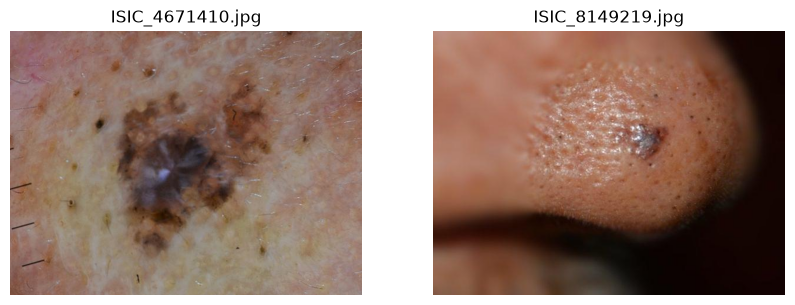

In [13]:
fig, axes = plt.subplots(1, len(images), figsize=(10,5))

for ax, img_path in zip(axes, images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path))
    ax.axis("off")

plt.show()

In [14]:
dataset = metadata.merge(groundtruth, on="lesion_id", how="left")

dataset = dataset.merge(supplement, on="isic_id", how="left")

print(dataset.shape)
dataset.head()

(10480, 31)


,lesion_id,image_type,isic_id,attribution,copyright_license,image_manipulation,age_approx,sex,skin_tone_class,site,...,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC,diagnosis_full,diagnosis_confirm_type,invasion_thickness_interval
0,IL_0000652,clinical: close-up,ISIC_8149219,MILK study team,CC-BY-NC,altered,70.0,male,1,head_neck_face,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Basal cell carcinoma,histopathology,NaN
1,IL_0000652,dermoscopic,ISIC_4671410,MILK study team,CC-BY-NC,instrument only,70.0,male,1,head_neck_face,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Basal cell carcinoma,histopathology,NaN
2,IL_0003176,clinical: close-up,ISIC_3904045,MILK study team,CC-BY-NC,instrument only,45.0,female,5,head_neck_face,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Basal cell carcinoma,histopathology,NaN
3,IL_0003176,dermoscopic,ISIC_5371928,MILK study team,CC-BY-NC,instrument only,45.0,female,5,head_neck_face,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Basal cell carcinoma,histopathology,NaN
4,IL_0004688,clinical: close-up,ISIC_0791494,MILK study team,CC-BY-NC,instrument only,50.0,male,3,lower_extremity,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Basal cell carcinoma,histopathology,NaN


In [16]:
dataset["image_type"].value_counts()

image_type
clinical: close-up    5240
dermoscopic           5240
Name: count, dtype: int64

In [21]:
clinical = dataset[dataset["image_type"] == "clinical: close-up"].copy()
dermoscopic = dataset[dataset["image_type"] == "dermoscopic"].copy()

print("Clinical:", clinical.shape)
print("Dermoscopic:", dermoscopic.shape)

Clinical: (5240, 31)
Dermoscopic: (5240, 31)


In [20]:
dataset["image_type"].value_counts()

image_type
clinical: close-up    5240
dermoscopic           5240
Name: count, dtype: int64

In [23]:
from pathlib import Path

INPUT_PATH = Path(DATA_PATH) / "MILK10k_Training_Input"

# Tüm JPG dosyalarını bul
image_files = list(INPUT_PATH.rglob("*.jpg"))

print(f"Bulunan JPG sayısı: {len(image_files)}")

# isic_id -> dosya yolu eşleştirmesi
image_map = {img.stem: str(img) for img in image_files}

# Dataset'e dosya yolunu ekle
dataset["image_path"] = dataset["isic_id"].map(image_map)

print("Eşleşen görüntü:", dataset["image_path"].notna().sum())
dataset[["isic_id", "image_path"]].head()

Bulunan JPG sayısı: 10480
Eşleşen görüntü: 10480


,isic_id,image_path
0,ISIC_8149219,../data/MILK10K/MILK10k_Training_Input/IL_0000...
1,ISIC_4671410,../data/MILK10K/MILK10k_Training_Input/IL_0000...
2,ISIC_3904045,../data/MILK10K/MILK10k_Training_Input/IL_0003...
3,ISIC_5371928,../data/MILK10K/MILK10k_Training_Input/IL_0003...
4,ISIC_0791494,../data/MILK10K/MILK10k_Training_Input/IL_0004...


In [24]:
clinical = dataset[dataset["image_type"] == "clinical: close-up"].copy()
dermoscopic = dataset[dataset["image_type"] == "dermoscopic"].copy()

paired = clinical.merge(
    dermoscopic[["lesion_id", "image_path"]].rename(
        columns={"image_path": "dermoscopic_path"}
    ),
    on="lesion_id",
    how="inner"
)

paired = paired.rename(columns={"image_path": "clinical_path"})

print("Clinical:", clinical.shape)
print("Dermoscopic:", dermoscopic.shape)
print("Paired:", paired.shape)

Clinical: (5240, 32)
Dermoscopic: (5240, 32)
Paired: (5240, 33)


In [25]:
from pathlib import Path

INPUT_PATH = Path(DATA_PATH) / "MILK10k_Training_Input"

# Tüm jpg dosyalarını bul
image_files = list(INPUT_PATH.rglob("*.jpg"))

print("Toplam JPG:", len(image_files))

# İlk 5 dosyayı görelim
for img in image_files[:5]:
    print(img.name)

Toplam JPG: 10480
ISIC_5682266.jpg
ISIC_8712502.jpg
ISIC_4375866.jpg
ISIC_7982662.jpg
ISIC_7343701.jpg


In [26]:
image_map = {}

for img in image_files:
    image_map[img.stem] = str(img)

dataset["image_path"] = dataset["isic_id"].map(image_map)

print("Eşleşen:", dataset["image_path"].notna().sum())
dataset[["isic_id", "image_path"]].head()

Eşleşen: 10480


,isic_id,image_path
0,ISIC_8149219,../data/MILK10K/MILK10k_Training_Input/IL_0000...
1,ISIC_4671410,../data/MILK10K/MILK10k_Training_Input/IL_0000...
2,ISIC_3904045,../data/MILK10K/MILK10k_Training_Input/IL_0003...
3,ISIC_5371928,../data/MILK10K/MILK10k_Training_Input/IL_0003...
4,ISIC_0791494,../data/MILK10K/MILK10k_Training_Input/IL_0004...


In [27]:
clinical = dataset[dataset["image_type"] == "clinical: close-up"].copy()
dermoscopic = dataset[dataset["image_type"] == "dermoscopic"].copy()

paired = clinical.merge(
    dermoscopic[["lesion_id", "image_path"]].rename(
        columns={"image_path": "dermoscopic_path"}
    ),
    on="lesion_id",
    how="inner"
)

paired = paired.rename(columns={"image_path": "clinical_path"})

print("Clinical:", clinical.shape)
print("Dermoscopic:", dermoscopic.shape)
print("Paired:", paired.shape)

Clinical: (5240, 32)
Dermoscopic: (5240, 32)
Paired: (5240, 33)


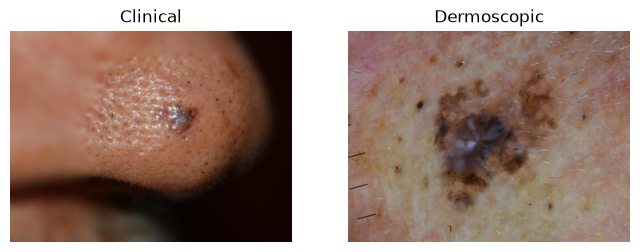

Label: Basal cell carcinoma
Age: 70.0
Sex: male


In [28]:
from PIL import Image
import matplotlib.pyplot as plt

row = paired.iloc[0]

fig, ax = plt.subplots(1,2, figsize=(8,4))

ax[0].imshow(Image.open(row["clinical_path"]))
ax[0].set_title("Clinical")
ax[0].axis("off")

ax[1].imshow(Image.open(row["dermoscopic_path"]))
ax[1].set_title("Dermoscopic")
ax[1].axis("off")

plt.show()

print("Label:", row["diagnosis_full"])
print("Age:", row["age_approx"])
print("Sex:", row["sex"])

In [29]:
from pathlib import Path

INPUT_PATH = Path(DATA_PATH) / "MILK10k_Training_Input"

# Tüm JPG dosyalarını bul
image_files = list(INPUT_PATH.rglob("*.jpg"))
print(f"Toplam JPG: {len(image_files)}")

# isic_id -> dosya yolu
image_map = {img.stem: str(img) for img in image_files}

# Dataset'e ekle
dataset["image_path"] = dataset["isic_id"].map(image_map)

print("Eşleşen görüntü:", dataset["image_path"].notna().sum())
dataset[["isic_id", "image_path"]].head()

Toplam JPG: 10480
Eşleşen görüntü: 10480


,isic_id,image_path
0,ISIC_8149219,../data/MILK10K/MILK10k_Training_Input/IL_0000...
1,ISIC_4671410,../data/MILK10K/MILK10k_Training_Input/IL_0000...
2,ISIC_3904045,../data/MILK10K/MILK10k_Training_Input/IL_0003...
3,ISIC_5371928,../data/MILK10K/MILK10k_Training_Input/IL_0003...
4,ISIC_0791494,../data/MILK10K/MILK10k_Training_Input/IL_0004...


In [30]:
clinical = dataset[dataset["image_type"] == "clinical: close-up"].copy()
dermoscopic = dataset[dataset["image_type"] == "dermoscopic"].copy()

paired = clinical.merge(
    dermoscopic[["lesion_id", "image_path"]].rename(
        columns={"image_path": "dermoscopic_path"}
    ),
    on="lesion_id",
    how="inner"
)

paired = paired.rename(columns={"image_path": "clinical_path"})

print("Clinical:", clinical.shape)
print("Dermoscopic:", dermoscopic.shape)
print("Paired:", paired.shape)

paired.head()

Clinical: (5240, 32)
Dermoscopic: (5240, 32)
Paired: (5240, 33)


,lesion_id,image_type,isic_id,attribution,copyright_license,image_manipulation,age_approx,sex,skin_tone_class,site,...,MAL_OTH,MEL,NV,SCCKA,VASC,diagnosis_full,diagnosis_confirm_type,invasion_thickness_interval,clinical_path,dermoscopic_path
0,IL_0000652,clinical: close-up,ISIC_8149219,MILK study team,CC-BY-NC,altered,70.0,male,1,head_neck_face,...,0.0,0.0,0.0,0.0,0.0,Basal cell carcinoma,histopathology,NaN,../data/MILK10K/MILK10k_Training_Input/IL_0000...,../data/MILK10K/MILK10k_Training_Input/IL_0000...
1,IL_0003176,clinical: close-up,ISIC_3904045,MILK study team,CC-BY-NC,instrument only,45.0,female,5,head_neck_face,...,0.0,0.0,0.0,0.0,0.0,Basal cell carcinoma,histopathology,NaN,../data/MILK10K/MILK10k_Training_Input/IL_0003...,../data/MILK10K/MILK10k_Training_Input/IL_0003...
2,IL_0004688,clinical: close-up,ISIC_0791494,MILK study team,CC-BY-NC,instrument only,50.0,male,3,lower_extremity,...,0.0,0.0,0.0,0.0,0.0,Basal cell carcinoma,histopathology,NaN,../data/MILK10K/MILK10k_Training_Input/IL_0004...,../data/MILK10K/MILK10k_Training_Input/IL_0004...
3,IL_0005081,clinical: close-up,ISIC_5667730,MILK study team,CC-BY-NC,instrument only,45.0,male,3,head_neck_face,...,0.0,0.0,0.0,1.0,0.0,"Squamous cell carcinoma, Invasive",histopathology,NaN,../data/MILK10K/MILK10k_Training_Input/IL_0005...,../data/MILK10K/MILK10k_Training_Input/IL_0005...
4,IL_0006177,clinical: close-up,ISIC_8803389,MILK study team,CC-BY-NC,instrument only,75.0,male,3,upper_extremity,...,0.0,0.0,0.0,0.0,0.0,Basal cell carcinoma,histopathology,NaN,../data/MILK10K/MILK10k_Training_Input/IL_0006...,../data/MILK10K/MILK10k_Training_Input/IL_0006...


In [31]:
class_columns = [
    "AKIEC","BCC","BEN_OTH","BKL","DF",
    "INF","MAL_OTH","MEL","NV","SCCKA","VASC"
]

paired["label"] = paired[class_columns].idxmax(axis=1)

paired["label"].value_counts()

label
BCC        2522
NV          746
BKL         544
SCCKA       473
MEL         450
AKIEC       303
DF           52
INF          50
VASC         47
BEN_OTH      44
MAL_OTH       9
Name: count, dtype: int64

In [32]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    paired,
    test_size=0.2,
    random_state=42,
    stratify=paired["label"]
)

train_df.to_csv("../data/train.csv", index=False)
val_df.to_csv("../data/val.csv", index=False)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)

Train: (4192, 34)
Validation: (1048, 34)
